# The Image Filter & Pixel Manipulation Engine


* The Scenario: You are tasked with building a basic version of Photoshop using only mathematical operations.
Creating Arrays & Attributes: You load a provided image (using a library like matplotlib.image to read it into a NumPy array). You must inspect .shape, .ndim, and .dtype to understand how the pixels and RGB channels are structured, and create a blank "canvas" using np.zeros().
* Indexing, Slicing & Masking: 
* Slicing: Crop the image to focus on a specific subject (e.g., img[100:500, 200:600]).
* Indexing: Isolate only the Red channel of the image.
* Masking: Create a "green screen" effect. Find all pixels where the green value is high and replace them with pixels from a completely * * different background array.
* Vectorization, Broadcasting & Ufuncs: Increase the image's brightness by simply adding a scalar value (e.g., img + 50 demonstrating broadcasting). Apply a gamma correction or vintage filter using np.power() and np.sqrt() (ufuncs) without writing a single for loop.
* Math & Stats: Find the brightest and darkest pixels in the image (np.max, np.min). Calculate the average pixel intensity of the image to determine if it is "overexposed" or “underexposed” (np.mean across specific axes).


* Creating Arrays & Attributes: You load a provided image (using a library like matplotlib.image to read it into a NumPy array). You must inspect .shape, .ndim, and .dtype to understand how the pixels and RGB channels are structured, and create a blank "canvas" using np.zeros().

In [2]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np


(1623, 1430, 3)
3
6962670
uint8


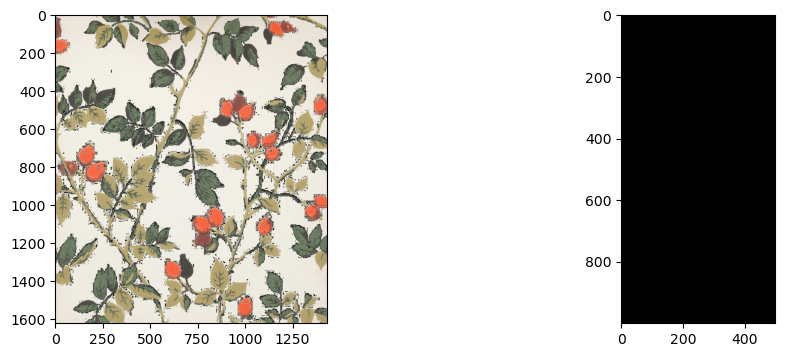

In [3]:
img_arr = plt.imread('photo1.jpg')
# Attributes 
print(img_arr.shape)
print(img_arr.ndim)
print(img_arr.size)
print(img_arr.dtype)

# create a blank 
blank_canvas = np.zeros(shape = (1000,500,3) )
plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
plt.imshow(img_arr)
plt.subplot(1,2,2)
plt.imshow(blank_canvas)


* Slicing: Crop the image to focus on a specific subject (e.g., img[100:500, 200:600]).
* Indexing: Isolate only the Red channel of the image.
* Masking: Create a "green screen" effect. Find all pixels where the green value is high and replace them with pixels from a completely different background array.


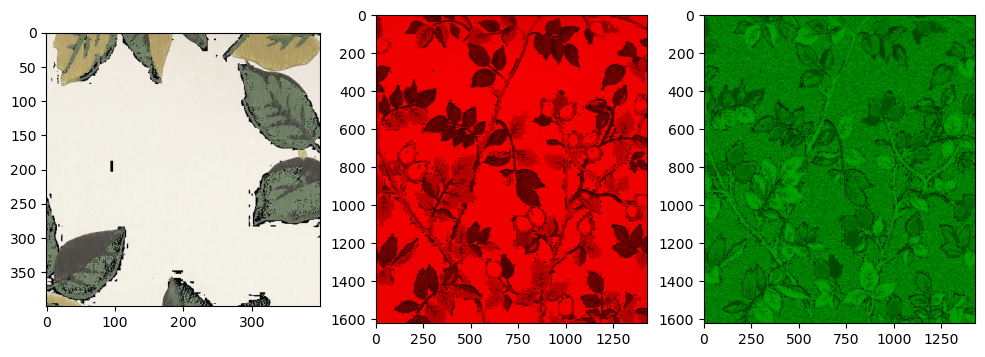

In [19]:
# slicing 
slicing = img_arr[100:500, 200:600]
plt.figure(figsize = (12,4))
plt.subplot(1,3,1)
plt.imshow(slicing)

# Red channel of the image
red_channel = img_arr.copy()
red_channel[:,:,1] = 0
red_channel[:,:,2] = 0
plt.subplot(1,3,2)
plt.imshow(red_channel)

# Create the Green Mask
x = img_arr.copy()
x[:,:,0] = 0
x[:,:,2] = 0 
only_green = x[:,:,1] >170
y = np.random.randint(0,255 , size = (len(x[only_green])) , dtype = 'uint8')
x[only_green,1] = y
z = x[:,:]
plt.subplot(1,3,3)
plt.imshow(z)

* Vectorization, Broadcasting & Ufuncs: Increase the image's brightness by simply adding a scalar value (e.g., img + 50 demonstrating broadcasting). Apply a gamma correction or vintage filter using np.power() and np.sqrt() (ufuncs) without writing a single for loop.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..15.9687195].


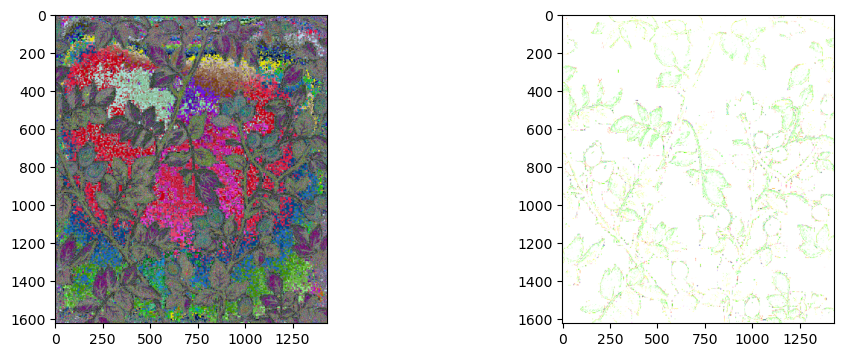

In [11]:
bright = img_arr + 50 
bright = np.clip(img_arr, 0 ,255)

correction = np.power(img_arr,2)
vintage = np.sqrt(img_arr , dtype = np.float32)
plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
plt.imshow(correction)
plt.subplot(1,2,2)
plt.imshow(vintage)


* Math & Stats: Find the brightest and darkest pixels in the image (np.max, np.min). Calculate the average pixel intensity of the image to determine if it is "overexposed" or “underexposed” (np.mean across specific axes).


In [12]:
brightest = np.max(img_arr)
darkest = np.min(img_arr)
pixel_average = np.average(img_arr)
print(brightest)
print(darkest)
print(pixel_average)

255
0
181.8578138846161
